# Concrete

Target Variable is Concrete Compressive Strength

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load Data

In [4]:
columns = [
    "Cement",
    "Blast_Furnace_Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age",
    "Concrete_Compressive_Strength",
]

df = pd.read_csv("../data/Concrete_Data.csv", names=columns, header=0)

df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Compressive_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


# Preprocessing

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 1030
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast_Furnace_Slag             1030 non-null   float64
 2   Fly_Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse_Aggregate               1030 non-null   float64
 6   Fine_Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete_Compressive_Strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


As we can see by looking at the shape of the data, there are no string values, so we can proceed with checking for missing values and outliers. The Concrete_Data dataset has 1030 instances and 9 features.

In [6]:
print("Missing values by column:")
print(df.isna().sum())

print("\nTotal missing values:", df.isna().sum().sum())

Missing values by column:
Cement                           0
Blast_Furnace_Slag               0
Fly_Ash                          0
Water                            0
Superplasticizer                 0
Coarse_Aggregate                 0
Fine_Aggregate                   0
Age                              0
Concrete_Compressive_Strength    0
dtype: int64

Total missing values: 0


There are no missing values in this dataset, so we can now check for outliers.

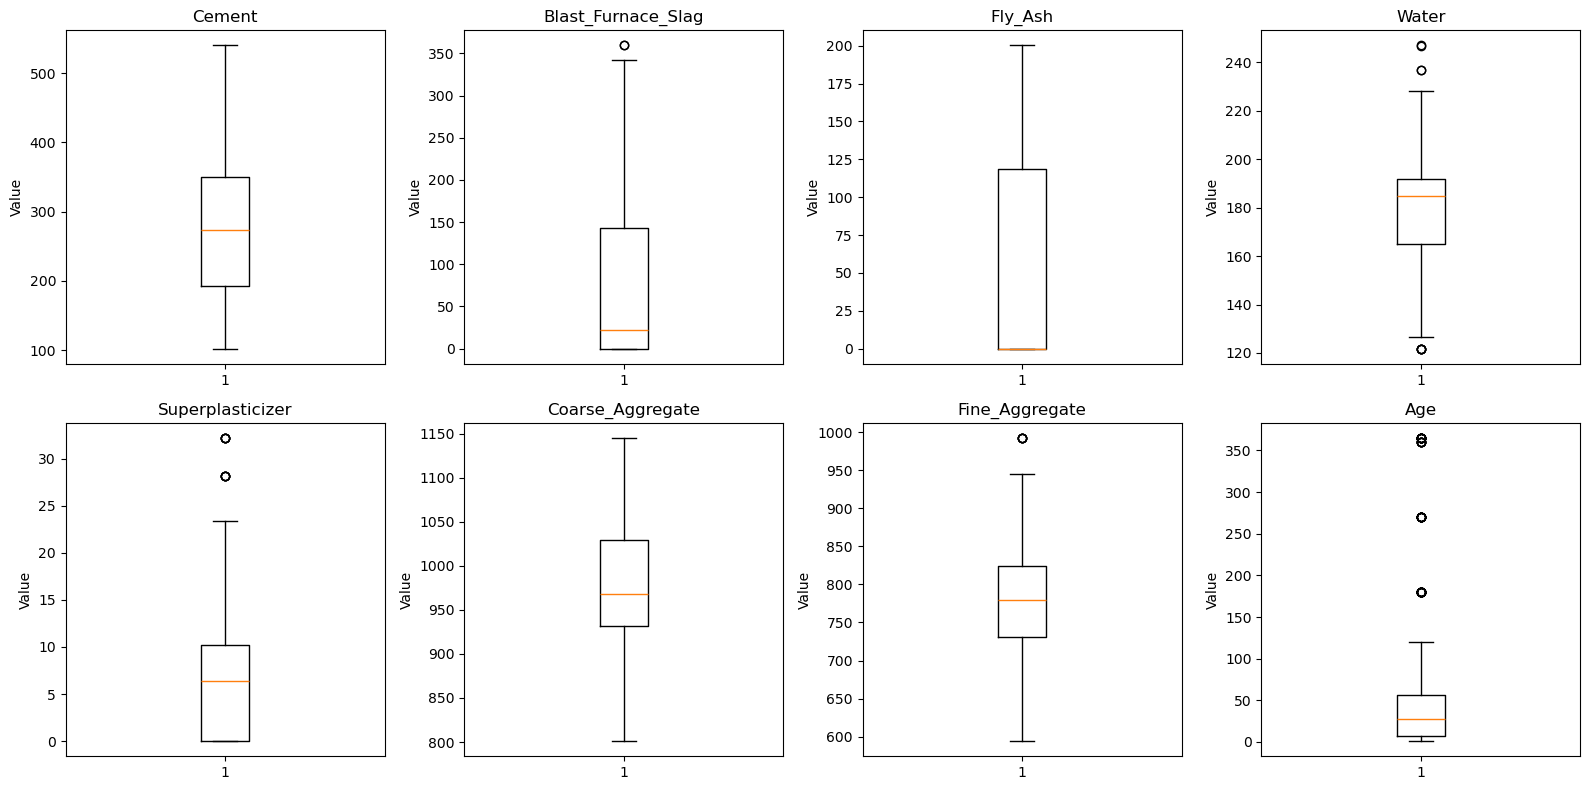

In [7]:
df.describe()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, column in zip(axes.flatten(), df.columns):
    ax.boxplot(df[column])
    ax.set_title(column)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

There are outliers in the columns `Age`, `Fine_Aggregate`, `Superplasticizer`, `Water`, and `Blast_Furnace_Slag`. 

In [8]:
outlier_counts = {}

for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = count
    
    print(f"{col}:")
    print(f"  Q1 = {q1:.2f}")
    print(f"  Q3 = {q3:.2f}")
    print(f"  IQR = {iqr:.2f}")
    print(f"  Lower bound = {lower:.2f}")
    print(f"  Upper bound = {upper:.2f}")
    print(f"  Potential outliers = {count}\n")

Cement:
  Q1 = 192.38
  Q3 = 350.00
  IQR = 157.62
  Lower bound = -44.06
  Upper bound = 586.44
  Potential outliers = 0

Blast_Furnace_Slag:
  Q1 = 0.00
  Q3 = 142.95
  IQR = 142.95
  Lower bound = -214.42
  Upper bound = 357.38
  Potential outliers = 2

Fly_Ash:
  Q1 = 0.00
  Q3 = 118.30
  IQR = 118.30
  Lower bound = -177.45
  Upper bound = 295.75
  Potential outliers = 0

Water:
  Q1 = 164.90
  Q3 = 192.00
  IQR = 27.10
  Lower bound = 124.25
  Upper bound = 232.65
  Potential outliers = 9

Superplasticizer:
  Q1 = 0.00
  Q3 = 10.20
  IQR = 10.20
  Lower bound = -15.30
  Upper bound = 25.50
  Potential outliers = 10

Coarse_Aggregate:
  Q1 = 932.00
  Q3 = 1029.40
  IQR = 97.40
  Lower bound = 785.90
  Upper bound = 1175.50
  Potential outliers = 0

Fine_Aggregate:
  Q1 = 730.95
  Q3 = 824.00
  IQR = 93.05
  Lower bound = 591.38
  Upper bound = 963.57
  Potential outliers = 5

Age:
  Q1 = 7.00
  Q3 = 56.00
  IQR = 49.00
  Lower bound = -66.50
  Upper bound = 129.50
  Potential outl

After looking at both the box-plot and using the IQR rule, we conclude that there ae outliers for the features `Blast_Furnace_Slag` (2), `Water` (9), `Superplasticizer` (10), `Fine_Aggregate` (5), `Age` (59), and the target variable `Concrete_Compressive_Strength` (4). However, we will not remove these outliers because they could have valid testing, for instance, the 59 outliers for `Age` should not be removed since they are valid ages for concrete testing

# Statistical Summaries

In [9]:
summary = df.describe().T.round(3)
summary

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.168,104.506,102.00,192.375,272.900,350.000,540.0
Blast_Furnace_Slag,1030.0,73.896,86.279,0.00,0.000,22.000,142.950,359.4
Fly_Ash,1030.0,54.188,63.997,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567,21.354,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.205,5.974,0.00,0.000,6.400,10.200,32.2
Coarse_Aggregate,1030.0,972.919,77.754,801.00,932.000,968.000,1029.400,1145.0
Fine_Aggregate,1030.0,773.580,80.176,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662,63.170,1.00,7.000,28.000,56.000,365.0
Concrete_Compressive_Strength,1030.0,35.818,16.706,2.33,23.710,34.445,46.135,82.6


This shows that there are many elements that have skewedness in this dataset, `Blast_Furnace_Slag`, `Fly_Ash`, `Superplasticizer`, and `Age` show this by differences in their means and medians.

# Correlation Matrix and Heatmap

In [10]:
corr = df.corr()

corr.round(3)

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Compressive_Strength
Cement,1.000,-0.275,-0.397,-0.082,0.092,-0.109,-0.223,0.082,0.498
Blast_Furnace_Slag,-0.275,1.000,-0.324,0.107,0.043,-0.284,-0.282,-0.044,0.135
Fly_Ash,-0.397,-0.324,1.000,-0.257,0.378,-0.010,0.079,-0.154,-0.106
Water,-0.082,0.107,-0.257,1.000,-0.658,-0.182,-0.451,0.278,-0.290
Superplasticizer,0.092,0.043,0.378,-0.658,1.000,-0.266,0.223,-0.193,0.366
Coarse_Aggregate,-0.109,-0.284,-0.010,-0.182,-0.266,1.000,-0.178,-0.003,-0.165
Fine_Aggregate,-0.223,-0.282,0.079,-0.451,0.223,-0.178,1.000,-0.156,-0.167
Age,0.082,-0.044,-0.154,0.278,-0.193,-0.003,-0.156,1.000,0.329
Concrete_Compressive_Strength,0.498,0.135,-0.106,-0.290,0.366,-0.165,-0.167,0.329,1.000


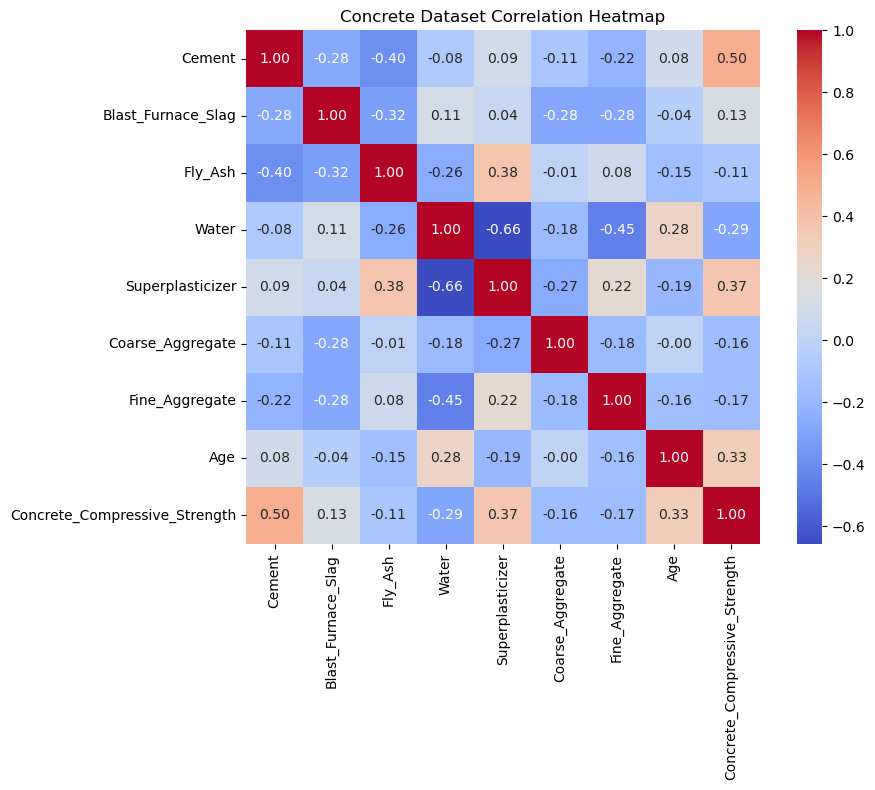

In [11]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Concrete Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()

In both the correlation matrix and the heatmap, we can see that the features that have the strongest correlation with `Concrete_Compressive_Strength` are `Cement` (0.498) and `Superplasticizer` (0.366).

# Top Two Predictor Variables

In [12]:
target = "Concrete_Compressive_Strength"

strength_corr = corr[target].drop(target).abs().sort_values(ascending=False)

print("Top two predictors:")
print(strength_corr.head(2))

Top two predictors:
Cement              0.497832
Superplasticizer    0.366079
Name: Concrete_Compressive_Strength, dtype: float64


# Simple Regression Models

Cement Statsmodels

In [13]:
cement = df["Cement"]
y = df["Concrete_Compressive_Strength"]

cement = sm.add_constant(cement)  

model_cement = sm.OLS(y, cement).fit()
print(model_cement.summary())

                                  OLS Regression Results                                 
Dep. Variable:     Concrete_Compressive_Strength   R-squared:                       0.248
Model:                                       OLS   Adj. R-squared:                  0.247
Method:                            Least Squares   F-statistic:                     338.7
Date:                           Sun, 06 Sep 2026   Prob (F-statistic):           1.32e-65
Time:                                   13:43:19   Log-Likelihood:                -4214.6
No. Observations:                           1030   AIC:                             8433.
Df Residuals:                               1028   BIC:                             8443.
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

Superplasticizer Statsmodels

In [14]:
sp = df["Superplasticizer"]
y = df["Concrete_Compressive_Strength"]

sp = sm.add_constant(sp)  

model_sp = sm.OLS(y, sp).fit()
print(model_sp.summary())

                                  OLS Regression Results                                 
Dep. Variable:     Concrete_Compressive_Strength   R-squared:                       0.134
Model:                                       OLS   Adj. R-squared:                  0.133
Method:                            Least Squares   F-statistic:                     159.1
Date:                           Sun, 06 Sep 2026   Prob (F-statistic):           5.13e-34
Time:                                   13:45:09   Log-Likelihood:                -4287.1
No. Observations:                           1030   AIC:                             8578.
Df Residuals:                               1028   BIC:                             8588.
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------